In [1]:
import pandas as pd
import numpy as np
import os

processed_path = os.path.join("..", "Data", "Processed")

transactions = pd.read_csv(os.path.join(processed_path, "transactions_clean.csv"))
transactions['InvoiceDate'] = pd.to_datetime(transactions['InvoiceDate'])

customer_segments = pd.read_csv(os.path.join(processed_path, "customer_segments.csv"))

transactions.shape, customer_segments.shape

((805549, 11), (5878, 7))

In [2]:
order_level = transactions.groupby(['Customer ID', 'Invoice']).agg(
    InvoiceDate=('InvoiceDate', 'first'),
    OrderValue=('TotalPrice', 'sum')
).reset_index()

order_level.head()

,Customer ID,Invoice,InvoiceDate,OrderValue
0,12346,491725,2009-12-14 08:34:00,45.0
1,12346,491742,2009-12-14 11:00:00,22.5
2,12346,491744,2009-12-14 11:02:00,22.5
3,12346,492718,2009-12-18 10:47:00,22.5
4,12346,492722,2009-12-18 10:55:00,1.0


In [3]:
!pip install lifetimes

In [4]:
from lifetimes.utils import summary_data_from_transaction_data

reference_date = transactions['InvoiceDate'].max() + pd.Timedelta(days=1)

lifetimes_summary = summary_data_from_transaction_data(
    order_level,
    customer_id_col='Customer ID',
    datetime_col='InvoiceDate',
    monetary_value_col='OrderValue',
    observation_period_end=reference_date
)

lifetimes_summary.head()

,frequency,recency,T,monetary_value
Customer ID,,,,
12346,7.0,400.0,726.0,11066.637143
12347,7.0,402.0,405.0,717.398571
12348,4.0,363.0,439.0,449.310000
12349,3.0,571.0,590.0,1120.056667
12350,0.0,0.0,311.0,0.000000


In [5]:
from lifetimes import BetaGeoFitter

bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(lifetimes_summary['frequency'], lifetimes_summary['recency'], lifetimes_summary['T'])

bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.651364,0.015182,0.621609,0.681120
alpha,61.907095,1.878058,58.226102,65.588088
a,0.046523,0.004465,0.037771,0.055275
b,0.603324,0.054718,0.496076,0.710571


In [6]:
from lifetimes import GammaGammaFitter

repeat_customers = lifetimes_summary[lifetimes_summary['frequency'] > 0]

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(repeat_customers['frequency'], repeat_customers['monetary_value'])

ggf.summary


,coef,se(coef),lower 95% bound,upper 95% bound
p,3.779184,0.079514,3.623337,3.935031
q,0.336454,0.005881,0.324928,0.347981
v,3.681967,0.080241,3.524695,3.839239


In [7]:
lifetimes_summary['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    lifetimes_summary['frequency'],
    lifetimes_summary['recency'],
    lifetimes_summary['T'],
    lifetimes_summary['monetary_value'],
    time=12,  # months
    freq='D',  # our T/recency are in days
    discount_rate=0.01  # monthly discount rate, standard small assumption
)

lifetimes_summary[['frequency', 'monetary_value', 'predicted_clv']].head(10)

c:\Users\karti\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,frequency,monetary_value,predicted_clv
Customer ID,,,
12346,7.0,11066.637143,25962.373049
12347,7.0,717.398571,3981.252162
12348,4.0,449.310000,1413.954074
12349,3.0,1120.056667,2179.239819
12350,0.0,0.000000,NaN
12351,0.0,0.000000,NaN
12352,8.0,338.261250,2161.109558
12353,1.0,89.000000,108.757026
12354,0.0,0.000000,NaN


In [8]:
lifetimes_summary = lifetimes_summary.reset_index()

customer_segments = customer_segments.merge(
    lifetimes_summary[['Customer ID', 'predicted_clv']],
    on='Customer ID',
    how='left'
)

customer_segments.groupby('Segment')['predicted_clv'].mean().round(2).sort_values(ascending=False)

Segment
Champions         5393.00
New/Occasional    1030.74
At-Risk            826.58
Lost/Inactive       92.87
Name: predicted_clv, dtype: float64

In [9]:
customer_segments.to_csv(os.path.join(processed_path, "customer_segments.csv"), index=False)

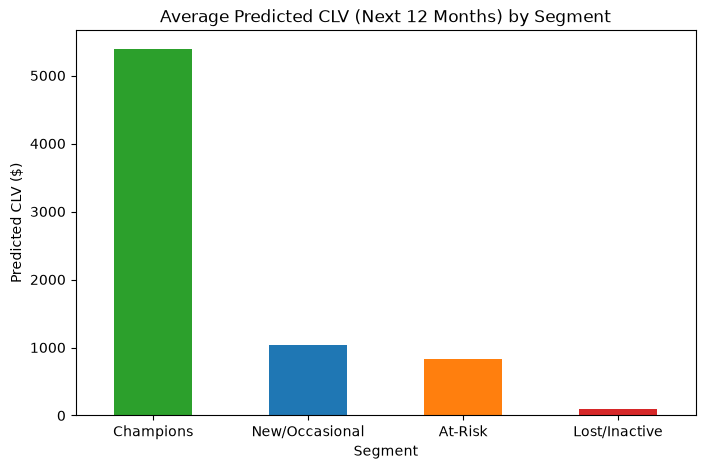

In [10]:
import matplotlib.pyplot as plt

clv_by_segment = customer_segments.groupby('Segment')['predicted_clv'].mean().round(2).sort_values(ascending=False)

plt.figure(figsize=(8,5))
clv_by_segment.plot(kind='bar', color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'])
plt.ylabel('Predicted CLV ($)')
plt.title('Average Predicted CLV (Next 12 Months) by Segment')
plt.xticks(rotation=0)
plt.show()